### 🤖 Hierarchical Agent Teams With RAG
In our previous example (Agent Supervisor), we introduced the concept of a single supervisor node to route work between different worker nodes.

But what if the job for a single worker becomes too complex? What if the number of workers becomes too large?

For some applications, the system may be more effective if work is distributed hierarchically.

You can do this by composing different subgraphs and creating a top-level supervisor, along with mid-level supervisors.

In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.tools.retriever import create_retriever_tool
from langchain_community.document_loaders import TextLoader, WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_tavily import TavilySearch
from langchain.agents import create_agent
from langgraph.graph import StateGraph, MessagesState, END
from typing import Literal, List, Annotated, Dict, Optional
from langgraph.types import Command
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_experimental.utilities import PythonREPL
from IPython.display import Markdown, display
from langchain_core.tools import tool
from langgraph_supervisor import create_supervisor
from pathlib import Path
from tempfile import TemporaryDirectory

In [2]:
load_dotenv()

True

In [3]:
_TEMP_DIRECTORY = TemporaryDirectory()
WORKING_DIRECTORY = Path(_TEMP_DIRECTORY.name)

In [4]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

if tavily_key is not None:
    os.environ["TAVILY_API_KEY"] = tavily_key
else: 
    raise ValueError("TAVILY_API_KEY environment variable is not set.")

In [5]:
llm = init_chat_model("openai:gpt-4o")

In [6]:
# 1. search_agent
#########################

# tools for search agent
#-------------------------
# 1. Tavily Tool
tavily_tool = TavilySearch(max_results=5)


# 2. Retriever Tool
#------------------------
# create retriever tool for research agent
docs=TextLoader('internal_docs.txt',encoding="utf-8").load()
chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
vs = FAISS.from_documents(chunks, OpenAIEmbeddings())
retriever = vs.as_retriever()

retriever_tool = create_retriever_tool(
    retriever,
    "retriever_tool_research_node",
    "Retriever Tool for the Research Node"
)

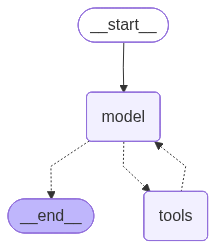

In [7]:
search_agent=create_agent(
    model=llm,
    tools=[tavily_tool, retriever_tool],
    name="search_agent"
)
search_agent

In [8]:
# search node
def search_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = search_agent.invoke(state)
    
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="search"
    )

    return Command(
        update={
            "messages": result["messages"],
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

In [9]:
# 2. sub agent: Web Scrapper Agent
###################################

# tools: scrape_webpages
@tool
def scrape_webpages(urls: List[str])->str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    loader = WebBaseLoader(web_paths=urls)
    docs = list(loader.lazy_load())

    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</Document>'
            for doc in docs
        ]
    )

In [10]:
web_scraper_agent = create_agent(
    llm, 
    tools=[scrape_webpages],
    name = "web_scraper_agent"
)

In [11]:
def web_scraper_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = web_scraper_agent.invoke(state)

    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="web_scrapper"
    )

    return Command(
        update={
            "messages": result["messages"],
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

In [12]:
# 3. Document Writer Agent
############################

# Tools: write_document, edit_document, read_document

@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    
    """Create and save a text document."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"

@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ],
) -> Annotated[str, "Path of the edited document file."]:
    
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            raise IndexError(
                f"Line number {line_number} is out of range. "
                f"File has {len(lines)} lines (valid range: 1 - {len(lines) + 1})."
            )

    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])

In [13]:
doc_writer_agent = create_agent(
    llm,
    tools=[write_document, edit_document, read_document],
    system_prompt=(
        """
        You can read, write and edit documents based on note-taker's outlines.
        Don't ask follow-up questions.
        """
    ),
    name = "doc_writer_agent"
)

In [14]:
def doc_writing_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = doc_writer_agent.invoke(state)
    
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="doc_writer"
    )

    return Command(
        update={
            "messages": result["messages"],
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

In [15]:
# 4. Note Taking Agent
##############################

# Tools: create_outline, read_document

@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    
    """Create and save an outline."""
    
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"

@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])

In [16]:
note_taking_agent = create_agent(
    llm,
    tools=[create_outline, read_document],
    system_prompt=(
        """
        You can read documents and create outlines for the document writer.
        Don't ask follow-up questions.
        """
    ),
    name = "note_taking_agent"
)

In [17]:
def note_taking_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = note_taking_agent.invoke(state)
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="note_taker"
    )

    return Command(
        update={
            "messages": result["messages"],
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

In [18]:
# 5. Chart Generating Agent
############################

# Tools: read_document, python_repl_tool

@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])

# Warning: This executes code locally, which can be unsafe when not sandboxed

repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """
    Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user.
    """
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"


In [19]:
chart_generating_agent = create_agent(
    llm, 
    tools=[read_document, python_repl_tool],
    name = "chart_generating_agent"
)

In [20]:
def chart_generating_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = chart_generating_agent.invoke(state)
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="chart_generator"
    )

    return Command(
        update={
            "messages": result["messages"],
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

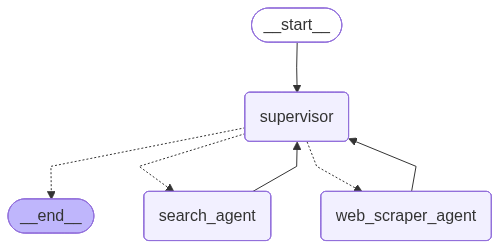

In [21]:
# Research Supervisor
research_graph = create_supervisor(
    model=llm,
    agents=[search_agent, web_scraper_agent],
    prompt=(
        """
        You are a supervisor tasked with managing a conversation between the
        following workers: [search_agent, web_scraper_agent]. Given the following user request,
        respond with the worker to act next. Each worker will perform a task and respond with their results and status.
        When finished, respond with FINISH.
        """
    ),
    add_handoff_back_messages=True,
    output_mode="full_history"
).compile(name="research_team")
research_graph

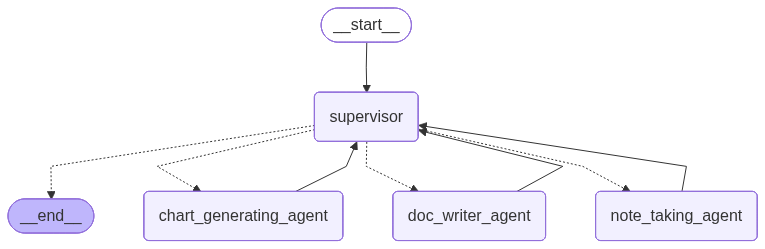

In [22]:
# Writing Supervisor
paper_writing_graph = create_supervisor(
    model=llm,
    agents=[doc_writer_agent, note_taking_agent, chart_generating_agent],
    prompt=(
        """
        You are a supervisor tasked with managing a conversation between the
        following workers: [doc_writer_agent, note_taking_agent, chart_generating_agent]. Given the following user request,
        respond with the worker to act next. Each worker will perform a task and respond with their results and status.
        When finished, respond with FINISH.
        """
    ),
    add_handoff_back_messages=True,
    output_mode="full_history"
).compile(name="writing_team")
paper_writing_graph

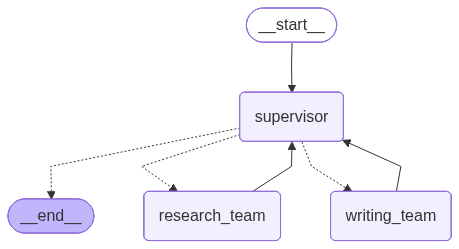

In [24]:
super_graph = create_supervisor(
    agents=[research_graph, paper_writing_graph],
    model=llm,
    prompt=(
        """
        You are a supervisor tasked with managing a conversation between the
        following workers: [research_team, writing_team]. Given the following user request,
        respond with the worker to act next. Each worker will perform a task and respond with their results and status.
        When finished, respond with FINISH.
        """
    ),
).compile()

super_graph

In [25]:
result = super_graph.invoke({
    "messages": [HumanMessage(content="Research the latest trends in AI and write a report about it.")]
})

# Print the final response
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research the latest trends in AI and write a report about it.
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_research_team (call_o9INVaZqtLRAKimBSWG8KzP0)
 Call ID: call_o9INVaZqtLRAKimBSWG8KzP0
  Args:
================================= Tool Message =================================
Name: transfer_to_research_team

Successfully transferred to research_team
================================== Ai Message ==================================
Name: supervisor

FINISH
================================== Ai Message ==================================
Name: research_team

Transferring back to supervisor
Tool Calls:
  transfer_back_to_supervisor (c063f9b0-6dee-4b21-b417-da6bcf973523)
 Call ID: c063f9b0-6dee-4b21-b417-da6bcf973523
  Args:
================================= Tool Message =================================
Name: transfer_back_to_su